In [2]:
import scanpy as sc
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
plt.style.use('ggplot')
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.facecolor"] = 'white'

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [ ]:

# Import data file
adata_nc = sc.read_visium('NC/outs')
adata_kd = sc.read_visium('KD_sample')

adata_nc.var_names_make_unique()
adata_kd.var_names_make_unique()

# add topic deconvoltuion
decon_nc = pd.read_csv(r"NC\outs\deconvolution\deconvolution_k8\deconvolved_spots_k8.csv", index_col=0)
decon_kd = pd.read_csv(r"KD\outs\deconvolution\deconvolution_k9\deconvolved_spots_k9.csv", index_col=0)

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata_nc.obs = adata_nc.obs.merge(decon_nc, left_index=True, right_index=True)
topic_cols = [f"Topic {i}" for i in range(1, 9)]
adata_nc.obs ["Topic"] = adata_nc.obs[topic_cols].idxmax(axis=1)

In [67]:
adata_kd.obs = adata_kd.obs.merge(decon_kd, left_index=True, right_index=True)
topic_cols = [f"Topic {i}" for i in range(1, 10)]
adata_kd.obs ["Topic"] = adata_kd.obs[topic_cols].idxmax(axis=1)

In [69]:
# Merge
# merge into one dataset
library_names = ["NC", "KD"]

adata = adata_nc.concatenate(
    adata_kd,
    batch_key="library_id",
    uns_merge="unique",
    batch_categories=library_names
)

adata

AnnData object with n_obs × n_vars = 4306 × 19465
    obs: 'in_tissue', 'array_row', 'array_col', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7', 'Topic 8', 'Topic', 'Topic 9', 'library_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [70]:
# Where images save 

adata.uns['spatial']['NC']['images']['hires'].shape

(2000, 1914, 3)

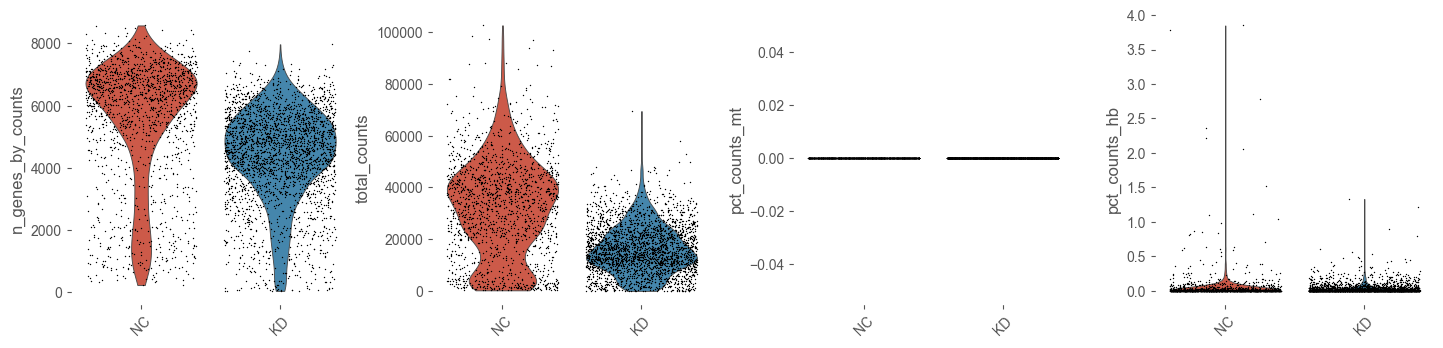

In [71]:
# add info on mitochondrial and hemoglobin genes to the objects.
adata.var['mt'] = adata.var_names.str.startswith('mt-') 
adata.var['hb'] = adata.var_names.str.contains(("^Hb.*-"))

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','hb'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_hb'], jitter=0.4, groupby = 'library_id', rotation= 45)

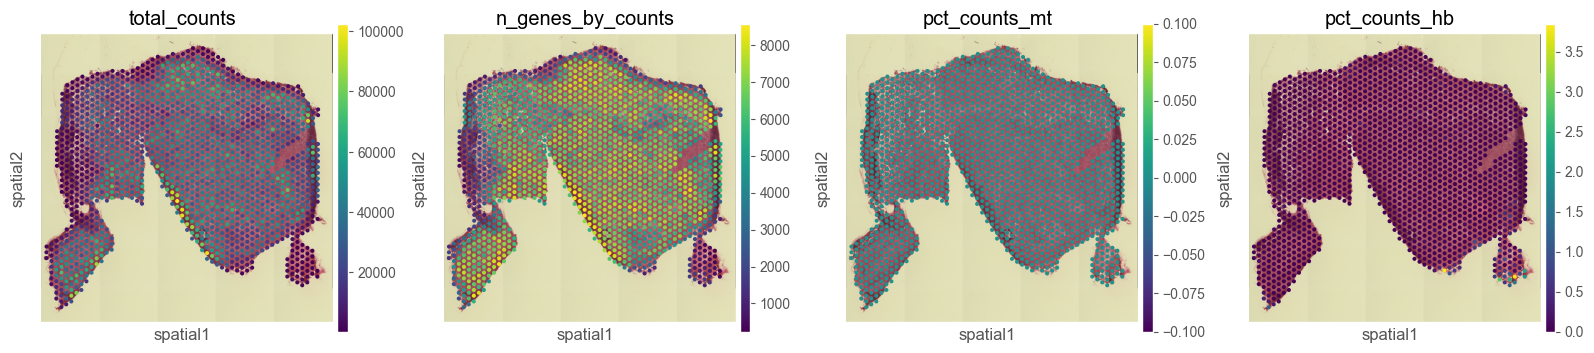

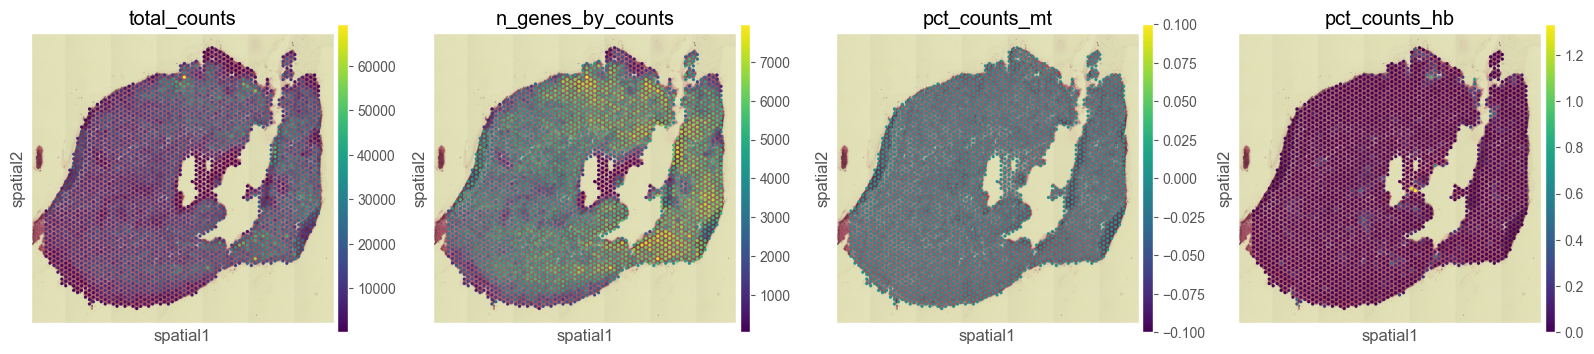

In [72]:
for library in library_names:
    sc.pl.spatial(adata[adata.obs.library_id == library,:], library_id=library, color = ["total_counts", "n_genes_by_counts",'pct_counts_mt', 'pct_counts_hb'])

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


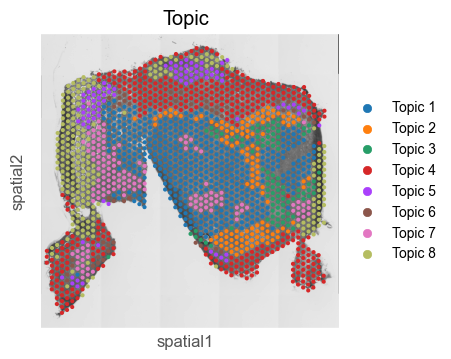

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


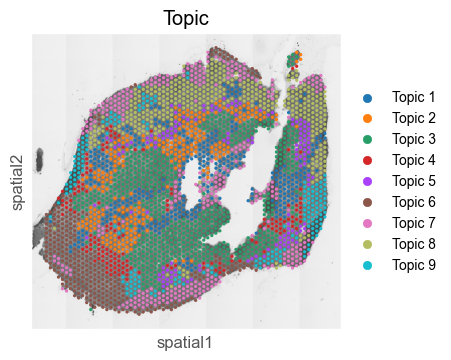

In [75]:
for library in library_names:
    sc.pl.spatial(adata[adata.obs.library_id == library,:], library_id=library, color = ["Topic"], bw=0.5)

In [10]:
# Check metrics file
# metrics = pd.read_csv("KD/outs/metrics_summary.csv")
# metrics

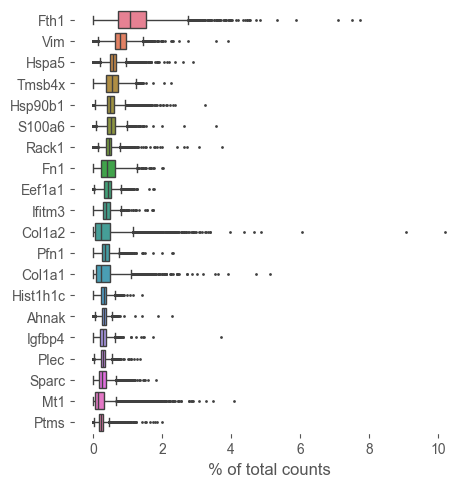

In [11]:
# Top expressed genes
sc.pl.highest_expr_genes(adata, n_top=20)

In [12]:
# Filter genes
# remove the Bc1 gene, hemoglobin genes (blood contamination) and the mitochondrial genes.
# https://nbisweden.github.io/workshop-scrnaseq-2024/labs/scanpy/scanpy_08_spatial.html
mito_genes = adata.var_names.str.startswith('mt-')
hb_genes = adata.var_names.str.contains('^Hb.*-')

remove = np.add(mito_genes, hb_genes)
remove[adata.var_names == "Bc1"] = True
keep = np.invert(remove)
print(sum(remove))

adata = adata[:,keep]

print(adata.n_obs, adata.n_vars)

7
4306 19458


<h3> Analysis

In [ ]:
# QC
adata = adata[adata.obs["pct_counts_mt"] < 20]
sc.pp.filter_genes(adata, min_cells=3)

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\preprocessing\_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


In [14]:
adata

AnnData object with n_obs × n_vars = 4306 × 14750
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'spatial', 'library_id_colors'
    obsm: 'spatial'

In [ ]:
counts_adata = adata.copy()

# Normalise data
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
# take 1500 variable genes per batch and then use the union of them.
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=1500, inplace=True, batch_key="library_id")

# subset for variable genes
adata.raw = adata
adata = adata[:,adata.var.highly_variable_nbatches > 0]

# scale data, will make ttest na in logfc
# sc.pp.scale(adata)

In [ ]:
# # To prepare for generate flux
# gene_list_scfea = pd.read_csv("select_genes_scfea.csv")['Gene'].tolist()
# gene_list_scfea1 = [gene.capitalize() for gene in gene_list_scfea]
# gene_list_scfea_upper = [gene.upper() for gene in gene_list_scfea]

# # pd.DataFrame(adata[:, gene_list_scfea1].X.toarray().T, index=gene_list_scfea_upper, columns=adata.obs_names).to_csv("spatial_ge_for_scfea.csv")
# pd.DataFrame(counts_adata[:, gene_list_scfea1].X.toarray().T, index=gene_list_scfea_upper, columns=counts_adata.obs_names).to_csv("spatial_ge_for_scfea_raw.csv")

## Flux analysis at reaction level

In [ ]:
#  Input flux
flux = pd.read_csv(r'Flux\spatial_norm\spatial_flux.csv', index_col=0)

# Module name
module_name = pd.read_csv(r'Flux\module_info_all_v1.csv', index_col=0)


In [18]:
# Check data
print("Sample size before preprocesing", flux.shape)
print(flux.isna().sum().sum())
print(flux.index.duplicated().sum())

# Remove small variance
var_cal = flux.var()
flux = flux.loc[:, var_cal > 1e-8].abs()
print("Sample size", flux.shape)
# flux.var(axis=1).min()

# Order
# # Make it the same shape with transcriptomcsi data
flux = flux.loc[adata.obs.index,:] 

# Super_module :Aggreate by mean 
flux_sm = pd.merge(module_name['Supermodule_name'], flux.T, left_index=True, right_index=True).groupby('Supermodule_name').mean().T

#  Map name
# module_name['Name'] = module_name['Compound_IN_name'] + "_" + module_name['Compound_OUT_name']
map_id =  dict(zip(module_name.index.astype(str), module_name["Module_name"]))
flux = flux.rename(columns=map_id)

Sample size before preprocesing (4306, 168)
0
0
Sample size (4306, 24)


In [19]:
# Convert anadata
adata_flux = sc.AnnData(flux)
# adata_flux.obs = adata_flux.obs.merge(meta_data, left_index=True, right_index=True)
adata_flux.obs = adata_flux.obs.merge(adata.obs.library_id, left_index=True, right_index=True)
adata_flux.obsm['spatial'] = adata.obsm['spatial'].copy()#adata_flux.obs[['array_row', 'array_col']].values
adata_flux.uns['spatial'] =adata.uns['spatial'].copy()

In [20]:
adata_flux.var

""
Glucose_G6P
G6P_G3P
Citrate_2OG
Succinate_Fumarate
Malate_Oxaloacetate
3PD_Serine
Cysteine_Pyruvate
Tyrosine_Fumarate
Arginine_Ornithine
Proline_Glyoxylate + pyruvate


In [21]:
nglycan = [
"Acetyl-CoA_(E,E)-Farnesyl-PP",
"(E,E)-Farnesyl-PP_Farnesal",
"Dolichyl phosphate_(GlcNAc)4 (Man)3 (Asn)1",
"(GlcNAc)4 (Man)3 (Asn)1_(Gal)2 (GlcNAc)4 (LFuc)1 (Man)3 (Neu5Ac)2 (Asn)1",
"(GlcNAc)4 (Man)3 (Asn)1_(GlcNAc)7 (Man)3 (Asn)1",
]
glyco = adata_flux.var.index[:6]

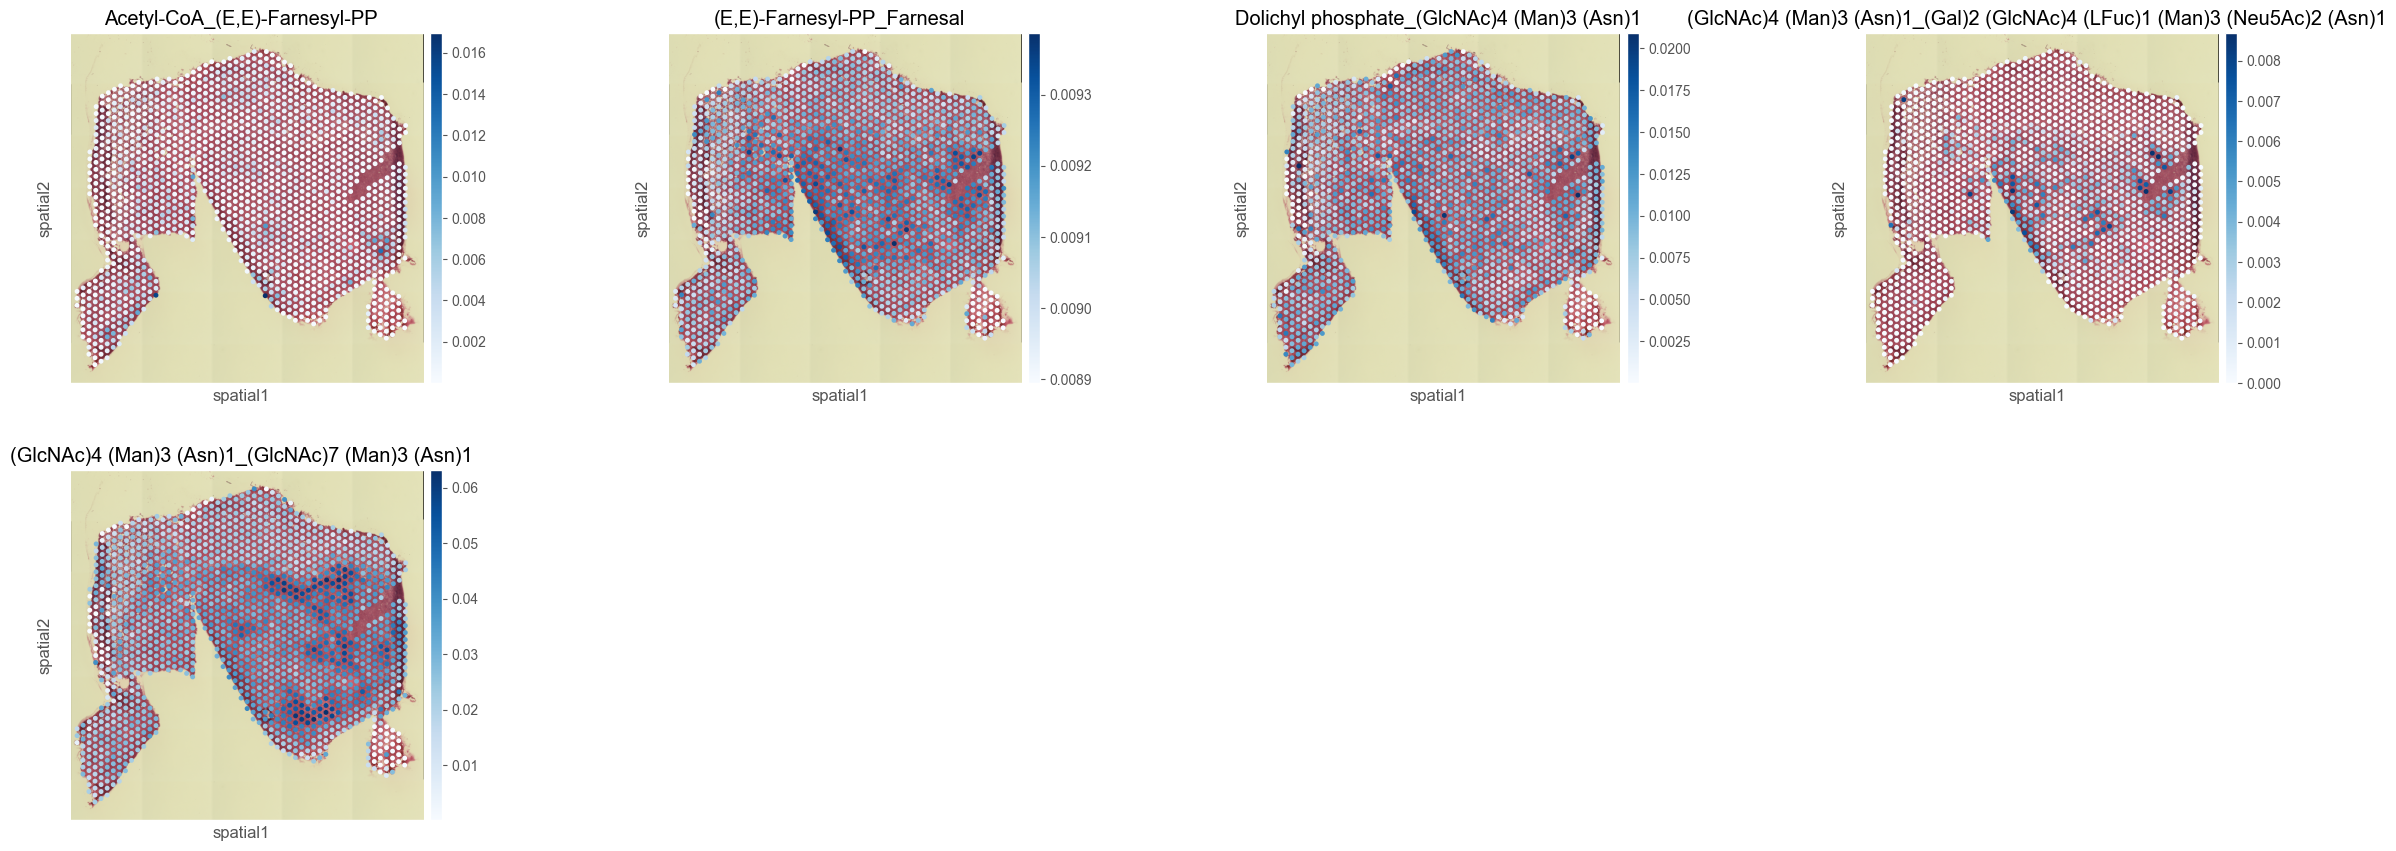

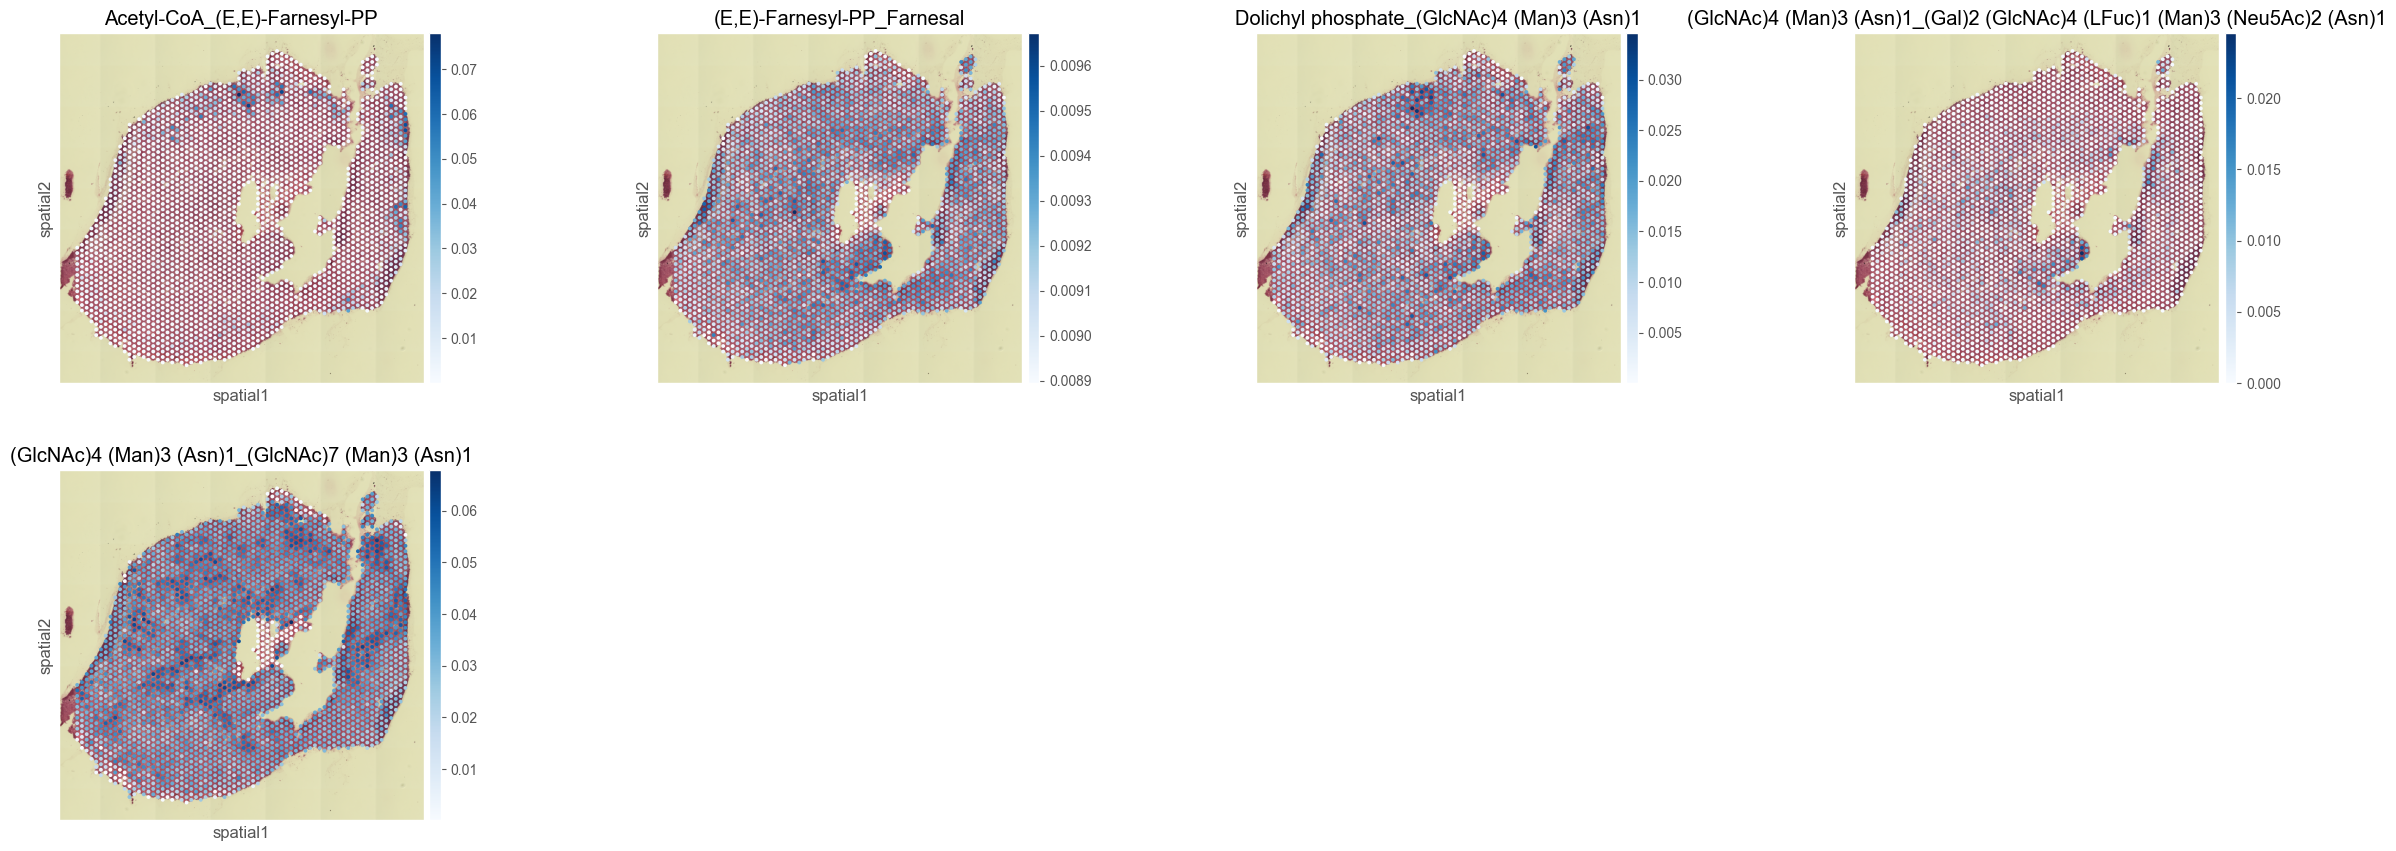

In [22]:
for library in library_names:
    sc.pl.spatial(adata_flux[adata_flux.obs.library_id == library,:], library_id=library, 
                  color = nglycan, cmap="Blues")

In [ ]:
# DE analysis
# find DE genes by t-test
key_DE = "library_id"
sc.tl.rank_genes_groups(adata_flux, key_DE, method="t-test", key_added=key_DE) #method="t-test",

# sc.pl.rank_genes_groups(adata_post, n_genes=15, sharey=False,
#                         key=key_DE,
#                         # save =f"Transcriptomic_{name_save}.pdf"
#                         )
results = adata_flux.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])

# To check DE flux
# de_gene = markers[(markers.pval_adj < 0.05)] #& (markers.lfc > 0.1)
markers.to_csv('Results/DE_flux.csv')

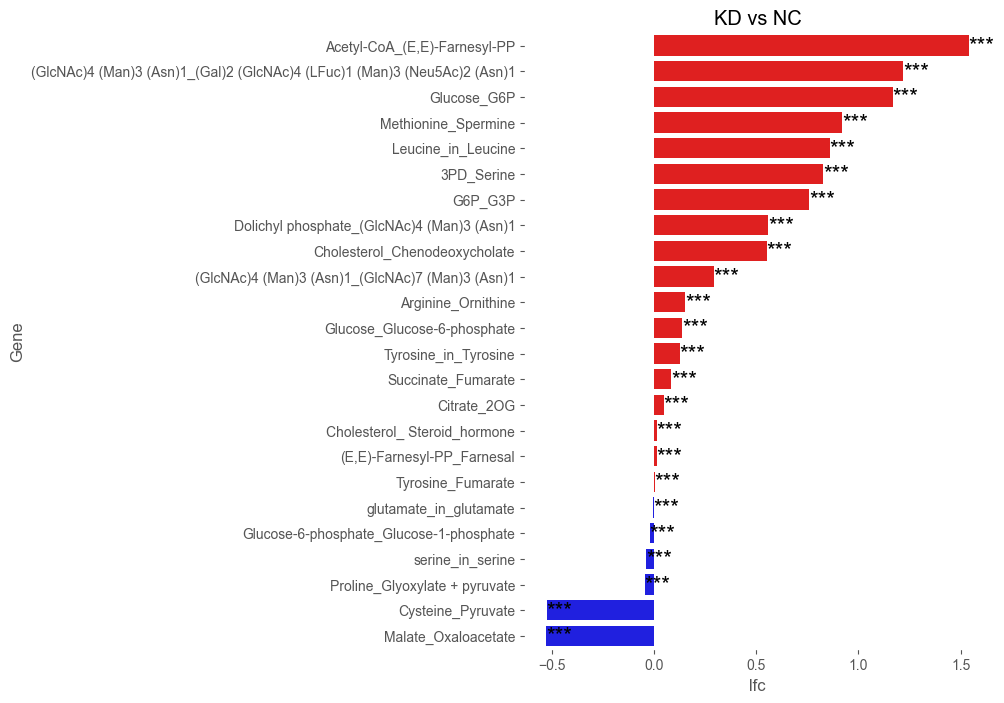

In [ ]:
gly_ =markers.query('cluster =="KD"').sort_values(by="lfc", ascending=False)
# gly_ =markers[(markers.pval_adj < 0.05)].query( 'Gene in@final_list & cluster =="T_cell"').sort_values(by="lfc", ascending=False)

colors = ['red' if float(lfc) >= 0 else 'blue' for lfc in gly_['lfc']]

fig, ax = plt.subplots(figsize=(6,8))
barplot = sns.barplot(
    data=gly_, 
    x="lfc", 
    y="Gene", 
    palette=colors, 
    dodge=False
)

# Add significance stars based on pval_adj
for i, (pval, lfc) in enumerate(zip(gly_['pval_adj'], gly_['lfc'])):
    pval = float(pval)
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = ''
    if star:
        ax.text(float(lfc), i, star, va='center', ha='left', color='black', fontsize=16)
# plt.xlim(-2,2)
plt.title(f'KD vs NC')
plt.savefig(f'Plot/all.pdf', dpi=300, bbox_inches='tight')

In [ ]:
# Normalise and scale data for flux
adata_flux.layers['norm']= (adata_flux.X - adata_flux.X.min(axis=0)) / (adata_flux.X.max(axis=0) - adata_flux.X.min(axis=0))
adata_flux.layers['scale'] = sc.pp.scale(adata_flux.X, zero_center=False)

In [25]:
adata

View of AnnData object with n_obs × n_vars = 4306 × 2689
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'spatial', 'library_id_colors', 'log1p', 'hvg'
    obsm: 'spatial'

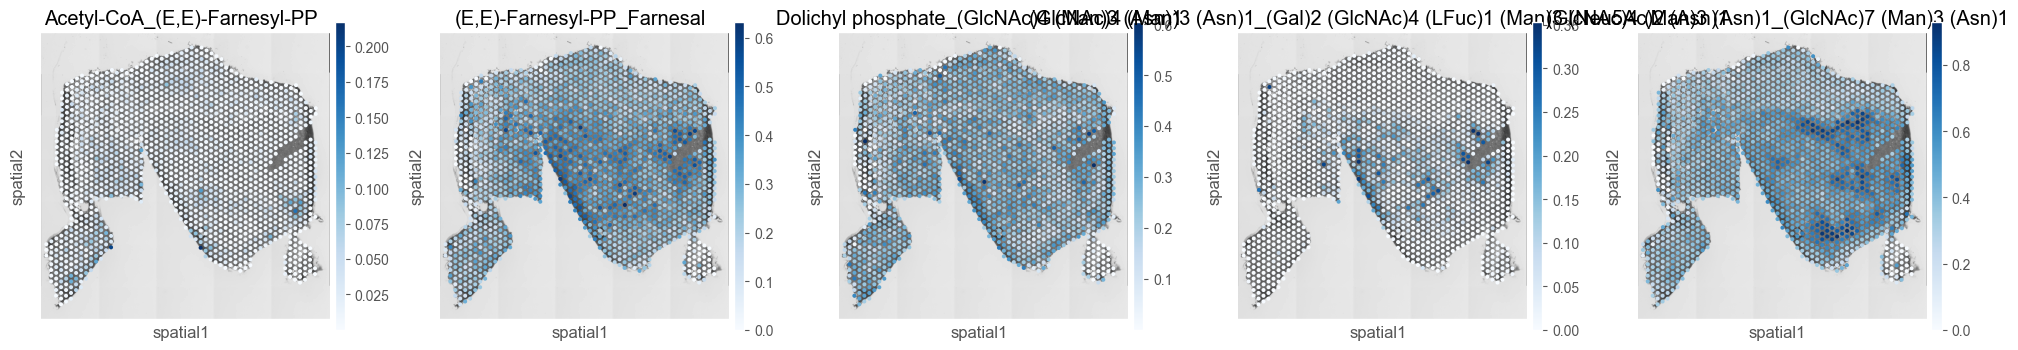

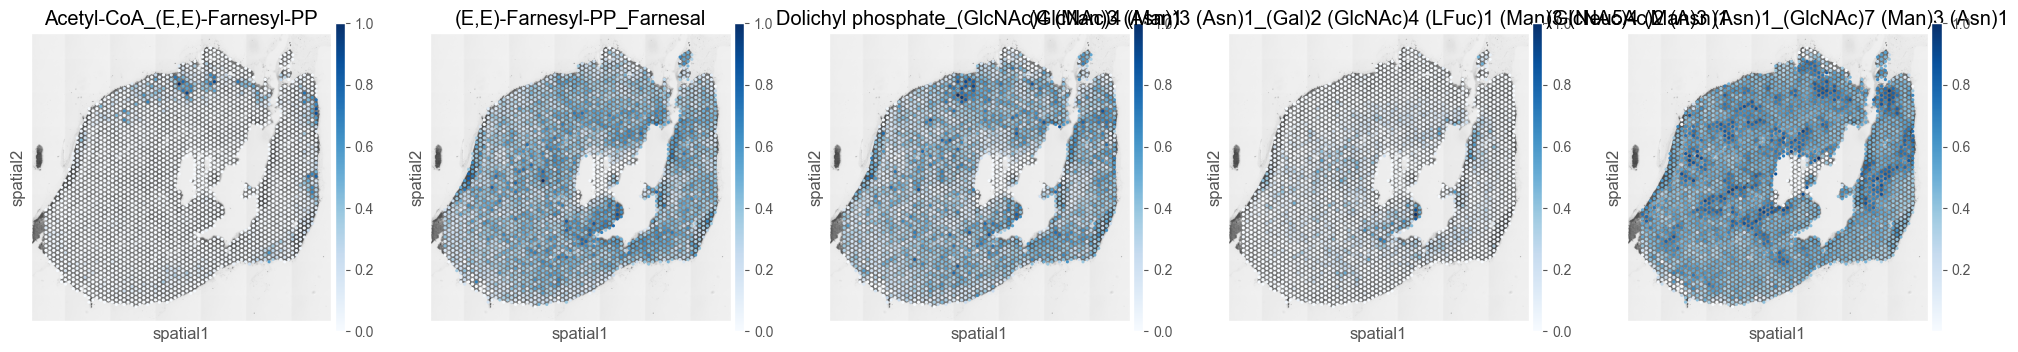

In [44]:

for library in library_names:
    sc.pl.spatial(adata_flux[adata_flux.obs.library_id == library,:], library_id=library, 
                  color = nglycan, cmap="Blues", layer="norm", bw=0.5,ncols=5, save=f"nglycan_reaction_{library}.pdf") #, vmin=0, vmax=1



<h3> PCA and clustering analysis

In [33]:
# metrics = pd.read_csv("KD/outs/metrics_summary.csv")
# metrics
# PCA, clustering
sc.pp.pca(adata_flux)
sc.pp.neighbors(adata_flux)
sc.tl.umap(adata_flux)
sc.tl.leiden(adata_flux)

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


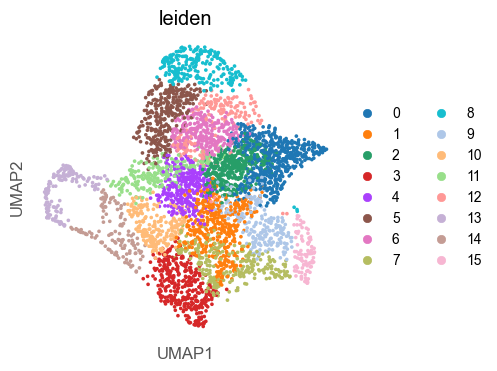

In [35]:

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata_flux, color=[ "leiden"], wspace=0.4)


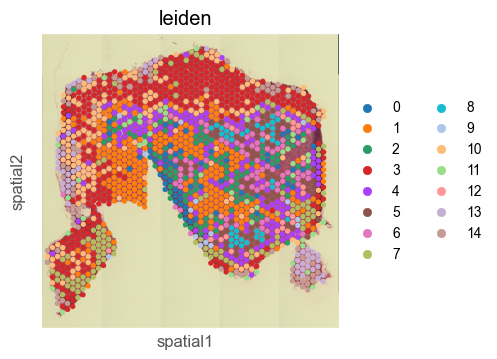

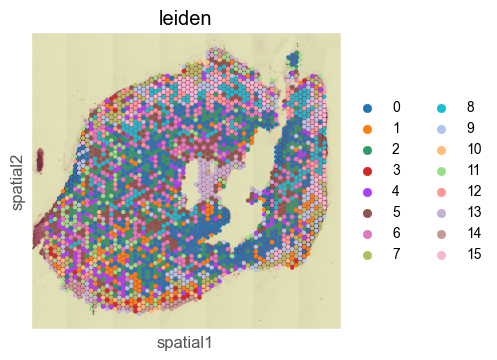

In [36]:
# sc.pl.spatial(adata, img_key="hires", color="leiden", 
#               library_id=['NC', 'KD'], size=1.5)

for library in library_names:
    sc.pl.spatial(adata_flux[adata_flux.obs.library_id == library,:], library_id=library, 
                  color = "leiden",size=1.3)


In [37]:
# bdata = adata[adata.obs.library_id == "NC"].copy()
adata.obs.library_id.value_counts()

library_id
KD    2730
NC    1576
Name: count, dtype: int64

## Pathway analysis

In [49]:

# Convert anadata
adata_flux_sm = sc.AnnData(flux_sm)
# adata_flux.obs = adata_flux.obs.merge(meta_data, left_index=True, right_index=True)
adata_flux_sm.obs = adata_flux_sm.obs.merge(adata.obs.library_id, left_index=True, right_index=True)
adata_flux_sm.obsm['spatial'] = adata.obsm['spatial'].copy()#adata_flux.obs[['array_row', 'array_col']].values
adata_flux_sm.uns['spatial'] =adata.uns['spatial'].copy()

In [50]:
# DE analysis
# find DE genes by t-test
key_DE = "library_id"
sc.tl.rank_genes_groups(adata_flux_sm, key_DE, method="t-test", key_added=key_DE) #method="t-test",

# sc.pl.rank_genes_groups(adata_post, n_genes=15, sharey=False,
#                         key=key_DE,
#                         # save =f"Transcriptomic_{name_save}.pdf"
#                         )
results = adata_flux_sm.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])

# de_gene = markers[(markers.pval_adj < 0.05)] #& (markers.lfc > 0.1)
# de_gene
# .query('Gene == "Fut8"')
markers.to_csv('DE_flux_sm.csv')

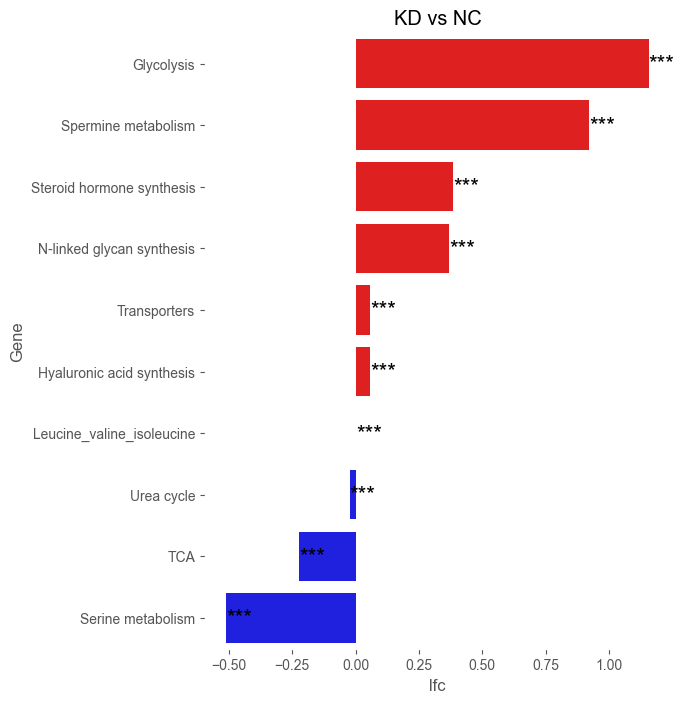

In [ ]:
gly_ =markers.query('cluster =="KD"').sort_values(by="lfc", ascending=False)
# gly_ =markers[(markers.pval_adj < 0.05)].query( 'Gene in@final_list & cluster =="T_cell"').sort_values(by="lfc", ascending=False)

colors = ['red' if float(lfc) >= 0 else 'blue' for lfc in gly_['lfc']]

fig, ax = plt.subplots(figsize=(6,8))
barplot = sns.barplot(
    data=gly_, 
    x="lfc", 
    y="Gene", 
    palette=colors, 
    dodge=False
)

# Add significance stars based on pval_adj
for i, (pval, lfc) in enumerate(zip(gly_['pval_adj'], gly_['lfc'])):
    pval = float(pval)
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = ''
    if star:
        ax.text(float(lfc), i, star, va='center', ha='left', color='black', fontsize=16)
# plt.xlim(-2,2)
plt.title(f'KD vs NC')
plt.savefig(f'Plot/pathway.pdf', dpi=300, bbox_inches='tight')

In [ ]:
# Normalise and scale data for flux
adata_flux_sm.layers['norm']= (adata_flux_sm.X - adata_flux_sm.X.min(axis=0)) / (adata_flux_sm.X.max(axis=0) - adata_flux_sm.X.min(axis=0))
adata_flux_sm.layers['scale'] = sc.pp.scale(adata_flux_sm.X, zero_center=False)

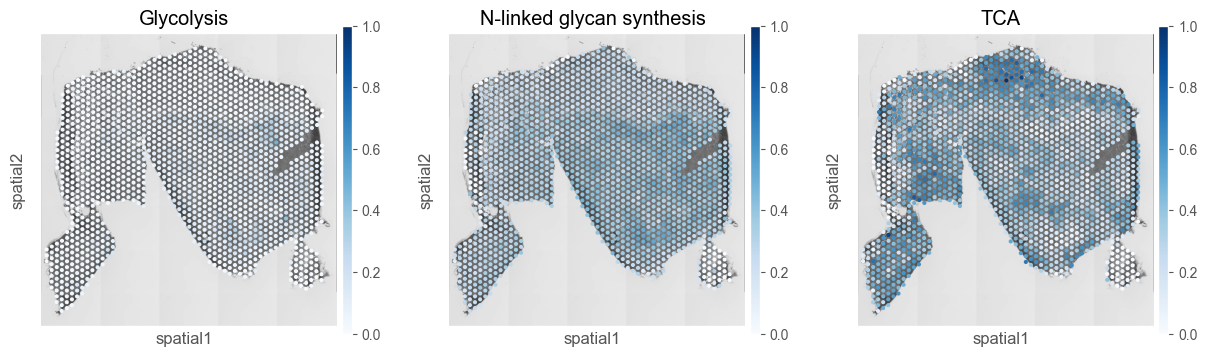

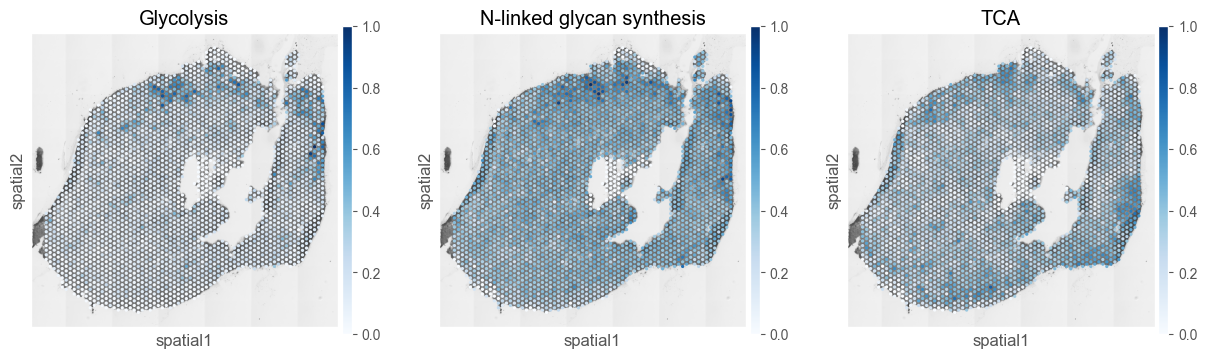

In [59]:
pathway_list = ['Glycolysis', 'N-linked glycan synthesis', 'TCA']

for library in library_names:
    sc.pl.spatial(adata_flux_sm[adata_flux_sm.obs.library_id == library,:], library_id=library, layer="norm",
                  color = pathway_list, cmap="Blues",  bw=0.5,ncols=5, save=f"pathway_{library}.pdf", vmin=0, vmax=1) #, 


